# Optimización de costos en microrred aislada con generadores diesel
**MILP, UC**  
Scheduling óptimo con Pyomo. Tiempos mínimos de uptime y downtime, linealización de costo de combustible basada en Parisio y restricciones de rampa.

Adaptado a PYOMO desde la implementación original en [https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html](https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html) y en el Ejemplo 12.15 del libro [Model Building in Mathematical Programming](https://share.google/ovWcmGq54LiyOcWm8) de H. Paul Williams (5ª edición, págs. 270-271 y 325-326).

Formulación MILP con:
- Satisfacción exacta de la demanda por período
- Restricción de reserva operativa (15% sobre la demanda)
- Costos fijos por generador activo, costos marginales y costos de arranque
- Objetivo: minimizar costo total de operación

V2: El problema de Williams de despacho nacional (≈ 45 GW) ha sido redimensionado a escala de microrred (≈ 2.1 MW pico), reemplazando los generadores térmicos convencionales por generadores diesel. Se implementan las siguientes extensiones respecto a la formulación original:

- Costos fijos de O&M (Operation and Maintenance) por generador activo
- Linealización Parisio de la curva cuadrática de costo de combustible
- Costos de apagado (`shutdown_cost`)
- Tiempos mínimos de encendido y apagado (`min_up_time`, `min_down_time`)

V3: Se pasa de una representación agregada de la demanda en 5 bloques horarios a una discretización horaria completa (24 períodos), lo cual permite capturar con mayor fidelidad las rampas de demanda, especialmente en los períodos de transición (mañana y tarde).

Esta mayor resolución temporal es clave para evaluar correctamente:
- decisiones de encendido/apagado de generadores,
- costos de arranque,
- y utilización de unidades en condiciones de carga parcial.

V4: Se agregan **restricciones de rampa** (ramp-up y ramp-down) para limitar la tasa de cambio de producción entre períodos consecutivos, protegiendo la vida útil de los generadores diesel y reflejando sus limitaciones mecánicas reales.


## Problema: Gestión Energética de Microrred con DDG

Una flota de 27 grupos generadores diesel está disponible para satisfacer la demanda eléctrica de una microrred aislada a lo largo de un día. Hay tres tipos de unidades diesel disponibles. Cada generador opera entre un nivel mínimo (50% de capacidad nominal) y un nivel máximo. Existen costos de O&M (operación y mantenimiento) fijos, costos de combustible (modelados con curva cuadrática linealizada), costos de arranque y de apagado. Cada unidad debe permanecer encendida/apagada un tiempo mínimo tras cada transición de estado. Los datos de demanda durante las 24 horas y las características de los generadores se muestran en la sección **Carga de datos**.

La capacidad total instalada es 2.730 kW (12×40 + 10×100 + 5×250). Considerando la reserva del 15%, la demanda máxima factible es ≈ 2.374 kW, por lo que el pico de 2.100 kW tiene margen de seguridad.

¿Qué generadores deberían estar funcionando en qué períodos para minimizar el costo total de operación?

### Notas sobre la configuración

- Capacidades (min/max_output): límite mínimo de generación en el 50% de la capacidad nominal, siguiendo las recomendaciones de Nemati et al. para garantizar eficiencia operativa aceptable.
- Costos de O&M (`cost_per_hour`): consumo fijo en vacío más mantenimiento (parámetro $c$ de Nemati). *No incluye combustible*, que se modela por separado con la curva cuadrática.
- Costos de combustible: curva $f(P) = a P^2 + b P$ [$/h] linealizada con 3 segmentos (enfoque Parisio).
- Costos de apagado (`shutdown_cost`): fijado en el 50% del costo de arranque (Nemati et al.).
- Tiempos mínimos: 1 hora para evitar ciclado excesivo (Parisio, 2014).
- **Límite de rampa (`ramp_limit`):** 50% de la capacidad máxima por hora (Parisio et al., Nemati et al.). Limita el cambio de producción entre períodos consecutivos para proteger los motores diesel.


## Linealización de la Curva de Costo de Combustible
### Enfoque Parisio (2014)

Dado que los MILP son computacionalmente más eficientes que los MIQP, la función de costo de combustible de un generador DDG

$$f(P) = a P^2 + b P \quad [\text{\$/h}]$$

se aproxima por el máximo de funciones afines sin introducir variables binarias adicionales:

$$f(P) \approx \sigma = \max_{j=1,\dots,n}\{S_j P + s_j\}$$

donde los coeficientes de cada segmento $j$ se obtienen evaluando la tangente de $f$ en el punto de soporte $P_j$:

$$S_j = f'(P_j) = 2aP_j + b \qquad s_j = f(P_j) - S_j P_j = -aP_j^2$$

Extensión a clases de generadores (formulación agregada): si hay $n_{g,t}$ unidades activas de la clase $g$ produciendo $x_{g,t}$ kW en total, el costo de combustible agregado es:

$$n_{g,t} \cdot f\!\left(\frac{x_{g,t}}{n_{g,t}}\right) = a\frac{x_{g,t}^2}{n_{g,t}} + b\, x_{g,t}$$

Con la aproximación lineal tangente en cada punto de soporte, esto se convierte en el conjunto de restricciones lineales:

$$\sigma_{g,t} \geq S_j \cdot x_{g,t} + s_j \cdot n_{g,t} \qquad \forall j = 1, \dots, n_{\mathrm{seg}}$$

Esta formulación es lineal porque $S_j$ y $s_j$ son constantes, $x_{g,t}$ es continua y $n_{g,t}$ es entera.

In [103]:
import pyomo.environ as pe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

## Creación de Archivos de Datos

Las siguientes celdas generan los archivos CSV con los parámetros de la microrred. Si ya existen, los sobreescribe.

In [104]:
os.makedirs("data", exist_ok=True)

# Los generadores pueden ciclar cada hora.
# ramp_limit = 50% de max_output [kW/h] — límite de rampa por clase
generators_csv = """generator_class,num_available,min_output,max_output,cost_per_hour,startup_cost,shutdown_cost,min_up_time,min_down_time,ramp_limit,state0
diesel_small,12,20.0,40.0,2.5,5.0,2.5,1,1,40.0,0
diesel_med,10,50.0,100.0,5.8,12.0,6.0,1,1,100.0,0
diesel_large,5,125.0,250.0,14.5,25.0,12.5,1,1,250.0,0
"""

with open("data/generators_diesel.csv", "w") as f:
    f.write(generators_csv)

# ── 24 períodos horarios — perfil típico de microrred residencial/rural ───────
# Curva de demanda diaria horaria escalada al rango 790–2100 kW.
# minimum_active_capacity = 1.15 × expected_demand (reserva operativa 15%)
demand_hourly = [
    820, 790, 810, 800, 830, 870,   # 00–05: valle nocturno
   1050,1380,1575,1420,1350,1380,   # 06–11: rampa matutina y mañana
   1520,1480,1400,1620,1850,2050,   # 12–17: tarde y rampa vespertina
   2100,1980,1750,1550,1350,1100,   # 18–23: pico y descenso nocturno
]

import datetime
base = datetime.datetime(2024, 1, 1, 0, 0, 0)
rows = []
for h, d in enumerate(demand_hourly):
    ts  = base + datetime.timedelta(hours=h)
    mac = round(d * 1.15, 2)
    rows.append(f"{ts},{d},{mac}")

time_periods_csv  = "time_period,expected_demand,minimum_active_capacity\n"
time_periods_csv += "\n".join(rows) + "\n"

with open("data/time_periods.csv", "w") as f:
    f.write(time_periods_csv)

print("Archivos CSV creados:")
print("   data/generators_diesel.csv  (MUT/MDT = 1 h, ramp_limit = 50% Pmax/h)")
print("   data/time_periods.csv       (24 períodos horarios)")
print()
print(f"  Demanda mínima  : {min(demand_hourly):>6} kW  (hora {demand_hourly.index(min(demand_hourly)):02d}:00)")
print(f"  Demanda máxima  : {max(demand_hourly):>6} kW  (hora {demand_hourly.index(max(demand_hourly)):02d}:00)")
print(f"  Demanda media   : {sum(demand_hourly)/len(demand_hourly):>6.0f} kW")
print(f"  Energía total   : {sum(demand_hourly):>6} kWh/día")
print()
print("Capacidad total instalada:")
print(f"  diesel_small : 12 × 40  kW = {12*40:>5} kW  |  ramp_limit = 20 kW/h")
print(f"  diesel_med   : 10 × 100 kW = {10*100:>5} kW  |  ramp_limit = 50 kW/h")
print(f"  diesel_large :  5 × 250 kW = {5*250:>5} kW  |  ramp_limit = 125 kW/h")
print(f"  TOTAL        :             = {12*40+10*100+5*250:>5} kW")


Archivos CSV creados:
   data/generators_diesel.csv  (MUT/MDT = 1 h, ramp_limit = 50% Pmax/h)
   data/time_periods.csv       (24 períodos horarios)

  Demanda mínima  :    790 kW  (hora 01:00)
  Demanda máxima  :   2100 kW  (hora 18:00)
  Demanda media   :   1368 kW
  Energía total   :  32825 kWh/día

Capacidad total instalada:
  diesel_small : 12 × 40  kW =   480 kW  |  ramp_limit = 20 kW/h
  diesel_med   : 10 × 100 kW =  1000 kW  |  ramp_limit = 50 kW/h
  diesel_large :  5 × 250 kW =  1250 kW  |  ramp_limit = 125 kW/h
  TOTAL        :             =  2730 kW


## Carga de Datos

In [105]:
generator_data = pd.read_csv(
    "data/generators_diesel.csv",
    index_col="generator_class",
)
generator_data

,num_available,min_output,max_output,cost_per_hour,startup_cost,shutdown_cost,min_up_time,min_down_time,ramp_limit,state0
generator_class,,,,,,,,,,
diesel_small,12,20.0,40.0,2.5,5.0,2.5,1,1,40.0,0
diesel_med,10,50.0,100.0,5.8,12.0,6.0,1,1,100.0,0
diesel_large,5,125.0,250.0,14.5,25.0,12.5,1,1,250.0,0


In [106]:
time_period_data = pd.read_csv(
    "data/time_periods.csv",
    parse_dates=["time_period"],
    index_col="time_period",
)
time_period_data

,expected_demand,minimum_active_capacity
time_period,,
2024-01-01 00:00:00,820,943.00
2024-01-01 01:00:00,790,908.50
2024-01-01 02:00:00,810,931.50
2024-01-01 03:00:00,800,920.00
2024-01-01 04:00:00,830,954.50
2024-01-01 05:00:00,870,1000.50
2024-01-01 06:00:00,1050,1207.50
2024-01-01 07:00:00,1380,1587.00
2024-01-01 08:00:00,1575,1811.25


## Conjuntos

In [107]:
GENERATORS   = list(generator_data.index)        # ['diesel_small', 'diesel_med', 'diesel_large']
TIME_PERIODS = list(time_period_data.index)       # lista de timestamps
T            = list(range(len(TIME_PERIODS)))     # índices enteros 0..4 para Pyomo

print(f"Clases de generadores : {GENERATORS}")
print(f"Número de períodos    : {len(T)}")
print(f"Períodos              :")
for i, t in enumerate(TIME_PERIODS):
    print(f"  t={i}  →  {t}")

Clases de generadores : ['diesel_small', 'diesel_med', 'diesel_large']
Número de períodos    : 24
Períodos              :
  t=0  →  2024-01-01 00:00:00
  t=1  →  2024-01-01 01:00:00
  t=2  →  2024-01-01 02:00:00
  t=3  →  2024-01-01 03:00:00
  t=4  →  2024-01-01 04:00:00
  t=5  →  2024-01-01 05:00:00
  t=6  →  2024-01-01 06:00:00
  t=7  →  2024-01-01 07:00:00
  t=8  →  2024-01-01 08:00:00
  t=9  →  2024-01-01 09:00:00
  t=10  →  2024-01-01 10:00:00
  t=11  →  2024-01-01 11:00:00
  t=12  →  2024-01-01 12:00:00
  t=13  →  2024-01-01 13:00:00
  t=14  →  2024-01-01 14:00:00
  t=15  →  2024-01-01 15:00:00
  t=16  →  2024-01-01 16:00:00
  t=17  →  2024-01-01 17:00:00
  t=18  →  2024-01-01 18:00:00
  t=19  →  2024-01-01 19:00:00
  t=20  →  2024-01-01 20:00:00
  t=21  →  2024-01-01 21:00:00
  t=22  →  2024-01-01 22:00:00
  t=23  →  2024-01-01 23:00:00


## Parámetros

Los parámetros del modelo se construyen como diccionarios Python a partir de los DataFrames cargados.

- $n_g$: unidades disponibles de la clase $g$
- $P^{\min}_g$, $P^{\max}_g$: límites de producción por unidad [kW]
- $c_g$: costo fijo de O&M por hora por unidad activa [$/h]
- $s^u_g$: costo de arranque [$]
- $s^d_g$: costo de apagado [$]
- $\tau^{\mathrm{up}}_g$, $\tau^{\mathrm{dn}}_g$: tiempos mínimos de encendido/apagado [períodos]
- $a^0_g$: estado inicial (unidades activas antes del primer período)
- $D_t$: demanda esperada en el período $t$ [kW]
- $\bar{D}_t$: capacidad activa mínima requerida en el período $t$ [kW]
- $S_j^g$, $s_j^g$: pendiente e intercepto del segmento $j$ de la curva de combustible de la clase $g$

In [108]:
# ── Parámetros por clase de generador ───────────────────────────────────────
num_available = generator_data['num_available'].to_dict()
min_output    = generator_data['min_output'].to_dict()
max_output    = generator_data['max_output'].to_dict()
cost_per_hour = generator_data['cost_per_hour'].to_dict()
startup_cost  = generator_data['startup_cost'].to_dict()
shutdown_cost = generator_data['shutdown_cost'].to_dict()
min_up_time   = generator_data['min_up_time'].to_dict()
min_down_time = generator_data['min_down_time'].to_dict()
ramp_limit    = generator_data['ramp_limit'].to_dict()
state0        = generator_data['state0'].to_dict()

# ── Parámetros por período (indexados por entero) ────────────────────────────
expected_demand         = {i: time_period_data['expected_demand'].iloc[i]         for i in T}
minimum_active_capacity = {i: time_period_data['minimum_active_capacity'].iloc[i] for i in T}

print('Parámetros cargados:')
for g in GENERATORS:
    print(f'  {g:<14}  Pmin={min_output[g]:>5} kW  Pmax={max_output[g]:>5} kW  ramp={ramp_limit[g]:>5} kW/h  ({100*ramp_limit[g]/max_output[g]:.0f}% Pmax)')


Parámetros cargados:
  diesel_small    Pmin= 20.0 kW  Pmax= 40.0 kW  ramp= 40.0 kW/h  (100% Pmax)
  diesel_med      Pmin= 50.0 kW  Pmax=100.0 kW  ramp=100.0 kW/h  (100% Pmax)
  diesel_large    Pmin=125.0 kW  Pmax=250.0 kW  ramp=250.0 kW/h  (100% Pmax)


## Linealización de la Curva de Costo de Combustible

Se definen los coeficientes cuadráticos de la función de costo de combustible por unidad:

$$f_g(P) = a_g P^2 + b_g P \quad [\text{\$/h}]$$

y se calculan los segmentos lineales evaluando las tangentes en $n_{\mathrm{seg}} = 3$ puntos de soporte equidistantes entre $P^{\min}_g$ y $P^{\max}_g$.

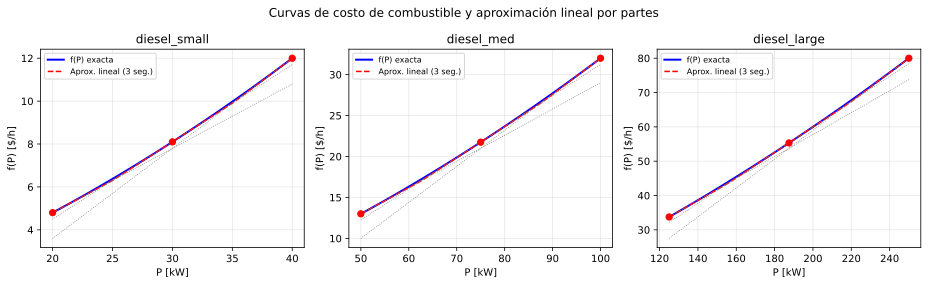


Segmentos lineales de la curva de combustible:
Clase           Seg   P_soporte (kW)   Pendiente S_j   Intercepto s_j
--------------------------------------------------------------------
diesel_small      0             20.0         0.30000          -1.2000
diesel_small      1             30.0         0.36000          -2.7000
diesel_small      2             40.0         0.42000          -4.8000

diesel_med        0             50.0         0.32000          -3.0000
diesel_med        1             75.0         0.38000          -6.7500
diesel_med        2            100.0         0.44000         -12.0000

diesel_large      0            125.0         0.32000          -6.2500
diesel_large      1            187.5         0.37000         -14.0625
diesel_large      2            250.0         0.42000         -25.0000



In [109]:
# ── Coeficientes de la curva cuadrática de combustible por clase ─────────────
# f(P) = a·P² + b·P  [$/h],  P en kW
# Los valores de 'a' capturan la no linealidad del consumo específico de combustible.
# Los valores de 'b' son consistentes con el costo marginal a carga media.
quad_params = {
    'diesel_small': {'a': 0.003,   'b': 0.18},   # $/(kW²·h), $/(kW·h)
    'diesel_med':   {'a': 0.0012,  'b': 0.20},
    'diesel_large': {'a': 0.0004,  'b': 0.22},
}

N_SEG = 3   # número de puntos de soporte para la linealización

# ── Cálculo de segmentos lineales ─────────────────────────────────────────────
# En cada punto P_j:
#   S_j = f'(P_j) = 2·a·P_j + b      (pendiente)
#   s_j = f(P_j) - S_j·P_j = -a·P_j² (intercepto por unidad)
lin_segments = {}   # {g: {'slopes': [...], 'intercepts': [...]}}

for g in GENERATORS:
    a  = quad_params[g]['a']
    b  = quad_params[g]['b']
    p_min = min_output[g]
    p_max = max_output[g]
    
    support_points = np.linspace(p_min, p_max, N_SEG)
    slopes     = [2 * a * pj + b for pj in support_points]
    intercepts = [-a * pj**2      for pj in support_points]
    lin_segments[g] = {'slopes': slopes, 'intercepts': intercepts, 'support': support_points}

SEGMENTS = list(range(N_SEG))   # índices de segmento: 0, 1, 2

# ── Visualización de las curvas y su aproximación ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Curvas de costo de combustible y aproximación lineal por partes", fontsize=12)

for ax, g in zip(axes, GENERATORS):
    a = quad_params[g]['a']
    b = quad_params[g]['b']
    p_min, p_max = min_output[g], max_output[g]
    
    P = np.linspace(p_min, p_max, 200)
    f_exact = a * P**2 + b * P
    
    # Aproximación por máximo de rectas
    segs = lin_segments[g]
    f_approx = np.max(
        np.array([segs['slopes'][j] * P + segs['intercepts'][j] for j in SEGMENTS]), axis=0
    )
    
    ax.plot(P, f_exact,  'b-',  lw=2,   label='f(P) exacta')
    ax.plot(P, f_approx, 'r--', lw=1.5, label='Aprox. lineal (3 seg.)')
    for j in SEGMENTS:
        Sj = segs['slopes'][j]; sj = segs['intercepts'][j]
        ax.plot(P, Sj * P + sj, 'gray', lw=0.8, ls=':')
    ax.scatter(segs['support'], [a*pj**2 + b*pj for pj in segs['support']],
               color='red', zorder=5, s=40)
    ax.set_xlabel("P [kW]"); ax.set_ylabel("f(P) [$/h]")
    ax.set_title(g); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Tabla resumen de segmentos ────────────────────────────────────────────────
print("\nSegmentos lineales de la curva de combustible:")
print(f"{'Clase':<14} {'Seg':>4} {'P_soporte (kW)':>16} {'Pendiente S_j':>15} {'Intercepto s_j':>16}")
print("-" * 68)
for g in GENERATORS:
    segs = lin_segments[g]
    for j in SEGMENTS:
        print(f"{g:<14} {j:>4} {segs['support'][j]:>16.1f} {segs['slopes'][j]:>15.5f} {segs['intercepts'][j]:>16.4f}")
    print()

## Construcción del Modelo Pyomo

In [110]:
model = pe.ConcreteModel(name="UC_Microgrid_Diesel")

## Conjuntos del Modelo

In [111]:
model.G = pe.Set(initialize=GENERATORS, doc="Clases de generadores diesel")
model.T = pe.Set(initialize=T, ordered=True, doc="Períodos de tiempo (índices enteros)")
model.J = pe.Set(initialize=SEGMENTS, doc="Segmentos de linealización de costo combustible")

## Parámetros del Modelo

In [112]:
model.num_available           = pe.Param(model.G, initialize=num_available,           doc='Unidades disponibles')
model.min_output              = pe.Param(model.G, initialize=min_output,              doc='Producción mínima [kW]')
model.max_output              = pe.Param(model.G, initialize=max_output,              doc='Producción máxima [kW]')
model.cost_per_hour           = pe.Param(model.G, initialize=cost_per_hour,           doc='Costo fijo O&M [$/h]')
model.startup_cost            = pe.Param(model.G, initialize=startup_cost,            doc='Costo de arranque [$]')
model.shutdown_cost           = pe.Param(model.G, initialize=shutdown_cost,           doc='Costo de apagado [$]')
model.min_up_time             = pe.Param(model.G, initialize=min_up_time,             doc='Tiempo mínimo encendido [períodos]')
model.min_down_time           = pe.Param(model.G, initialize=min_down_time,           doc='Tiempo mínimo apagado [períodos]')
model.ramp_limit              = pe.Param(model.G, initialize=ramp_limit,              doc='Límite de rampa [kW/h]')
model.state0                  = pe.Param(model.G, initialize=state0,                  doc='Estado inicial')
model.expected_demand         = pe.Param(model.T, initialize=expected_demand,         doc='Demanda esperada [kW]')
model.minimum_active_capacity = pe.Param(model.T, initialize=minimum_active_capacity, doc='Capacidad activa mínima [kW]')

# ── Parámetros de linealización (indexados por clase × segmento) ─────────────
slope_data     = {(g, j): lin_segments[g]['slopes'][j]     for g in GENERATORS for j in SEGMENTS}
intercept_data = {(g, j): lin_segments[g]['intercepts'][j] for g in GENERATORS for j in SEGMENTS}

model.lin_slope     = pe.Param(model.G, model.J, initialize=slope_data,     doc='Pendiente S_j del segmento j de la clase g')
model.lin_intercept = pe.Param(model.G, model.J, initialize=intercept_data, doc='Intercepto s_j del segmento j de la clase g')


## Resumen de Variables de Decisión

A continuación se listan **todas las variables de decisión** del modelo, con su tipo, dominio y significado físico.

### Variables Continuas

| Variable | Índices | Dominio | Unidad | Descripción |
| :--- | :---: | :---: | :---: | :--- |
| $x_{g,t}$ (`output`) | $g \in G,\; t \in T$ | $\mathbb{R}_{\geq 0}$ | kW | Producción total de la clase $g$ en el período $t$ |
| $\sigma_{g,t}$ (`sigma`) | $g \in G,\; t \in T$ | $\mathbb{R}_{\geq 0}$ | $/h | Costo de combustible total de la clase $g$ en $t$ (variable auxiliar de linealización) |

### Variables Enteras

| Variable | Índices | Dominio | Unidad | Descripción |
| :--- | :---: | :---: | :---: | :--- |
| $n_{g,t}$ (`num_active`) | $g \in G,\; t \in T$ | $\{0, 1, \ldots, n_g\}$ | unidades | Número de generadores de la clase $g$ activos en el período $t$ |
| $u_{g,t}$ (`num_startup`) | $g \in G,\; t \in T$ | $\mathbb{Z}_{\geq 0}$ | unidades | Número de generadores de la clase $g$ que **arrancan** en el período $t$ |
| $v_{g,t}$ (`num_shutdown`) | $g \in G,\; t \in T$ | $\mathbb{Z}_{\geq 0}$ | unidades | Número de generadores de la clase $g$ que **se apagan** en el período $t$ |

### Relación entre Variables de Transición de Estado

Las variables enteras satisfacen la identidad de balance:

$$n_{g,t} - n_{g,t-1} = u_{g,t} - v_{g,t} \qquad \forall g,\; t > t_0$$

### Dimensiones del Modelo

| Tipo | Cantidad |
| :--- | :---: |
| Clases de generadores ($|G|$) | 3 |
| Períodos de tiempo ($|T|$) | 24 |
| Segmentos de linealización ($|J|$) | 3 |
| Variables continuas (`output` + `sigma`) | $2 \times |G| \times |T|$ = **144** |
| Variables enteras (`num_active` + `num_startup` + `num_shutdown`) | $3 \times |G| \times |T|$ = **216** |
| **Total variables** | **360** |


## Definición de Variables

In [113]:
# ── Variable continua: producción total de la clase g en el período t [kW] ──
model.output = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeReals,
    doc="Producción total [kW]"
)

# ── Variable continua: costo de combustible total clase g en período t [$/h] ─
# Variable auxiliar de linealización Parisio: sigma_{g,t} = max_j { S_j·x + s_j·n }
model.sigma = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeReals,
    doc="Costo total de combustible [$/h] — variable de linealización Parisio"
)

# ── Variable entera: generadores activos (cota superior = num_available[g]) ──
def num_active_bounds(m, g, t):
    return (0, m.num_available[g])

model.num_active = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeIntegers,
    bounds=num_active_bounds,
    doc="Número de generadores activos"
)

# ── Variable entera: generadores que arrancan en el período t ─────────────────
model.num_startup = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeIntegers,
    doc="Número de arranques por período"
)

# ── Variable entera: generadores que se apagan en el período t ───────────────
model.num_shutdown = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeIntegers,
    doc="Número de apagados por período"
)

## Restricciones

### 1. Satisfacción de la Demanda

La producción total de todos los generadores en cada período debe igualar la demanda prevista:

$$\sum_{g \in G} x_{g,t} = D_t \qquad \forall t \in T$$

In [114]:
def demand_rule(m, t):
    return sum(m.output[g, t] for g in m.G) == m.expected_demand[t]

model.demand_constraint = pe.Constraint(
    model.T, rule=demand_rule,
    doc="Producción total = demanda esperada"
)

### 2. Restricción de Reserva Operativa

Los generadores activos deben tener capacidad suficiente para cubrir un 15% adicional de demanda ajustando la producción de las unidades ya encendidas:

$$\sum_{g \in G} P^{\max}_g \cdot n_{g,t} \geq \bar{D}_t \qquad \forall t \in T$$

In [115]:
def reserve_rule(m, t):
    return sum(m.max_output[g] * m.num_active[g, t] for g in m.G) >= m.minimum_active_capacity[t]

model.reserve_constraint = pe.Constraint(
    model.T, rule=reserve_rule,
    doc="Capacidad activa máxima >= capacidad mínima requerida"
)

### 3. Límites de Producción por Unidad Activa

Cada generador activo opera entre su mínimo técnico y su máximo técnico:

$$P^{\min}_g \cdot n_{g,t} \leq x_{g,t} \leq P^{\max}_g \cdot n_{g,t} \qquad \forall g \in G, t \in T$$

In [116]:
def output_lower_rule(m, g, t):
    return m.output[g, t] >= m.min_output[g] * m.num_active[g, t]

model.output_lower = pe.Constraint(
    model.G, model.T, rule=output_lower_rule,
    doc="Producción >= mínimo × generadores activos"
)

def output_upper_rule(m, g, t):
    return m.output[g, t] <= m.max_output[g] * m.num_active[g, t]

model.output_upper = pe.Constraint(
    model.G, model.T, rule=output_upper_rule,
    doc="Producción <= máximo × generadores activos"
)

### 4. Balance de Estado: Arranques

La variable $u_{g,t}$ captura el incremento neto de unidades activas entre períodos.

**Períodos $t > t_0$:**
$$u_{g,t} \geq n_{g,t} - n_{g,t-1} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

**Primer período $t_0$:**
$$u_{g,t_0} \geq n_{g,t_0} - a^0_g \qquad \forall g \in G$$

In [117]:
def startup_rule(m, g, t):
    if t == m.T.first():
        return pe.Constraint.Skip
    t_prev = m.T.prev(t)
    return m.num_startup[g, t] >= m.num_active[g, t] - m.num_active[g, t_prev]

model.startup_constraint = pe.Constraint(
    model.G, model.T, rule=startup_rule,
    doc="Arranques en t >= incremento de activos respecto a t-1"
)

def initial_startup_rule(m, g):
    t0 = m.T.first()
    return m.num_startup[g, t0] >= m.num_active[g, t0] - m.state0[g]

model.initial_startup = pe.Constraint(
    model.G, rule=initial_startup_rule,
    doc="Arranques en t₀ >= activos en t₀ − estado inicial"
)

### 5. Balance de Estado: Apagados

Simétricamente, $v_{g,t}$ captura el decremento neto de unidades activas.

**Períodos $t > t_0$:**
$$v_{g,t} \geq n_{g,t-1} - n_{g,t} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

**Primer período $t_0$:**
$$v_{g,t_0} \geq a^0_g - n_{g,t_0} \qquad \forall g \in G$$

In [118]:
def shutdown_rule(m, g, t):
    if t == m.T.first():
        return pe.Constraint.Skip
    t_prev = m.T.prev(t)
    return m.num_shutdown[g, t] >= m.num_active[g, t_prev] - m.num_active[g, t]

model.shutdown_constraint = pe.Constraint(
    model.G, model.T, rule=shutdown_rule,
    doc="Apagados en t >= decremento de activos respecto a t-1"
)

def initial_shutdown_rule(m, g):
    t0 = m.T.first()
    return m.num_shutdown[g, t0] >= m.state0[g] - m.num_active[g, t0]

model.initial_shutdown = pe.Constraint(
    model.G, rule=initial_shutdown_rule,
    doc="Apagados en t₀ >= estado inicial − activos en t₀"
)

### 6. Tiempo Mínimo de Encendido (Min Up-Time)

Si la clase $g$ arranca $u_{g,k}$ unidades en el período $k$, todas deben permanecer encendidas durante al menos $\tau^{\mathrm{up}}_g$ períodos consecutivos:

$$\sum_{k=t-\tau^{\mathrm{up}}_g+1}^{t} u_{g,k} \leq n_{g,t} \qquad \forall g \in G,\; t \geq \tau^{\mathrm{up}}_g$$

Esto garantiza que las unidades arrancadas en el horizonte $[t-\tau^{\mathrm{up}}+1,\, t]$ estén activas en $t$.

In [119]:
def min_up_time_rule(m, g, t):
    mut = int(pe.value(m.min_up_time[g]))
    if mut <= 1:
        return pe.Constraint.Skip   # trivialmente satisfecho con las restricciones de arranque
    t_list = list(m.T)
    if t < mut - 1:
        return pe.Constraint.Skip
    # Suma de arranques en la ventana [t-mut+1 .. t]
    window = [t_list[k] for k in range(t - mut + 1, t + 1) if k >= 0]
    return sum(m.num_startup[g, tau] for tau in window) <= m.num_active[g, t_list[t]]

model.min_up_time_constraint = pe.Constraint(
    model.G, model.T, rule=min_up_time_rule,
    doc="Tiempo mínimo de encendido: unidades arrancadas deben permanecer activas MUT períodos"
)

### 7. Tiempo Mínimo de Apagado (Min Down-Time)

Simétricamente, las unidades apagadas en el período $k$ deben permanecer apagadas durante al menos $\tau^{\mathrm{dn}}_g$ períodos:

$$\sum_{k=t-\tau^{\mathrm{dn}}_g+1}^{t} v_{g,k} \leq n_g - n_{g,t} \qquad \forall g \in G,\; t \geq \tau^{\mathrm{dn}}_g$$

In [120]:
def min_down_time_rule(m, g, t):
    mdt = int(pe.value(m.min_down_time[g]))
    if mdt <= 1:
        return pe.Constraint.Skip
    t_list = list(m.T)
    if t < mdt - 1:
        return pe.Constraint.Skip
    window = [t_list[k] for k in range(t - mdt + 1, t + 1) if k >= 0]
    return sum(m.num_shutdown[g, tau] for tau in window) <= m.num_available[g] - m.num_active[g, t_list[t]]

model.min_down_time_constraint = pe.Constraint(
    model.G, model.T, rule=min_down_time_rule,
    doc="Tiempo mínimo de apagado: unidades cerradas deben permanecer inactivas MDT períodos"
)

### 8. Linealización de la Curva de Combustible (Enfoque Parisio)

Para cada segmento $j$ de la aproximación lineal, se impone que $\sigma_{g,t}$ sea mayor o igual al costo de combustible calculado con la recta tangente en el punto de soporte $j$:

$$\sigma_{g,t} \geq S_j^g \cdot x_{g,t} + s_j^g \cdot n_{g,t} \qquad \forall g \in G,\; t \in T,\; j \in J$$

Como $\sigma_{g,t}$ aparece con signo positivo en el objetivo (minimización), el solver lo fijará en el máximo de las rectas tangentes, reproduciendo la envolvente convexa de la curva cuadrática.

In [121]:
def fuel_cost_linearization_rule(m, g, t, j):
    return m.sigma[g, t] >= m.lin_slope[g, j] * m.output[g, t] + m.lin_intercept[g, j] * m.num_active[g, t]

model.fuel_cost_linearization = pe.Constraint(
    model.G, model.T, model.J, rule=fuel_cost_linearization_rule,
    doc="Linealización Parisio: sigma >= S_j·x + s_j·n para cada segmento j"
)

### 9. Restricciones de Rampa (Ramp-Up y Ramp-Down)

Los generadores diesel no pueden cambiar su producción de forma instantánea. Se limita la tasa de cambio de producción entre períodos consecutivos para proteger los motores y reflejar la realidad operativa.

La formulación correcta para clases **agregadas** de generadores debe descontar el efecto de arranques y apagados — un generador que arranca en $t$ puede contribuir hasta su máximo sin violar la rampa, y uno que se apaga no penaliza la bajada:

**Rampa de subida:**
$$x_{g,t} - x_{g,t-1} \leq R_g \cdot n_{g,t-1} + P^{\max}_g \cdot u_{g,t} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

**Rampa de bajada:**
$$x_{g,t-1} - x_{g,t} \leq R_g \cdot n_{g,t} + P^{\max}_g \cdot v_{g,t} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

Donde $R_g$ es el límite de rampa [kW/h] de la clase $g$ (50% de $P^{\max}_g$). Los términos $P^{\max}_g \cdot u_{g,t}$ y $P^{\max}_g \cdot v_{g,t}$ permiten que las unidades recién arrancadas/apagadas contribuyan libremente, evitando que la restricción sea artificialmente activa durante transiciones de encendido/apagado.

> **Nota sobre la formulación:** una versión simplificada usaría $R_g \cdot n_{g,t}$ en ambas restricciones, pero sobrerestringiría los casos donde el número de activos cambia entre períodos. La formulación implementada sigue el enfoque de Morales-España et al. y es consistente con Parisio para modelos agregados.


In [122]:
def ramp_up_rule(m, g, t):
    if t == m.T.first():
        return pe.Constraint.Skip
    t_prev = m.T.prev(t)
    # Δx_up ≤ R·n_{t-1} + Pmax·u_t
    # Las unidades que arrancan en t pueden contribuir hasta Pmax sin violar la rampa
    return (m.output[g, t] - m.output[g, t_prev]
            <= m.ramp_limit[g] * m.num_active[g, t_prev]
               + m.max_output[g] * m.num_startup[g, t])

model.ramp_up_constraint = pe.Constraint(
    model.G, model.T, rule=ramp_up_rule,
    doc='Límite de rampa de subida'
)

def ramp_down_rule(m, g, t):
    if t == m.T.first():
        return pe.Constraint.Skip
    t_prev = m.T.prev(t)
    # Δx_down ≤ R·n_t + Pmax·v_t
    # Las unidades que se apagan en t no penalizan la bajada
    return (m.output[g, t_prev] - m.output[g, t]
            <= m.ramp_limit[g] * m.num_active[g, t]
               + m.max_output[g] * m.num_shutdown[g, t])

model.ramp_down_constraint = pe.Constraint(
    model.G, model.T, rule=ramp_down_rule,
    doc='Límite de rampa de bajada'
)

print('Restricciones de rampa agregadas:')
for g in GENERATORS:
    print(f'  {g:<14}  ramp_limit = {ramp_limit[g]:>5} kW/h  ({100*ramp_limit[g]/max_output[g]:.0f}% Pmax/h)')


Restricciones de rampa agregadas:
  diesel_small    ramp_limit =  40.0 kW/h  (100% Pmax/h)
  diesel_med      ramp_limit = 100.0 kW/h  (100% Pmax/h)
  diesel_large    ramp_limit = 250.0 kW/h  (100% Pmax/h)


## Función Objetivo

Se minimiza el costo total de operación, compuesto por cuatro términos:

$$\min \sum_{g \in G} \sum_{t \in T} \left[
  \underbrace{c_g \cdot n_{g,t}}_{\text{O\&M fijo}}
  + \underbrace{\sigma_{g,t}}_{\text{combustible (Parisio)}}
  + \underbrace{s^u_g \cdot u_{g,t}}_{\text{arranque}}
  + \underbrace{s^d_g \cdot v_{g,t}}_{\text{apagado}}
\right]$$

La variable $\sigma_{g,t}$ reemplaza el término lineal de costo marginal de la formulación original, capturando la curvatura del consumo específico de combustible diesel.

In [123]:
def obj_rule(m):
    return sum(
        # Costo fijo de O&M por generadores activos
        m.cost_per_hour[g]  * m.num_active[g, t]
        # Costo de combustible (aproximación lineal Parisio)
        + m.sigma[g, t]
        # Costo de arranque
        + m.startup_cost[g]  * m.num_startup[g, t]
        # Costo de apagado
        + m.shutdown_cost[g] * m.num_shutdown[g, t]
        for g in m.G
        for t in m.T
    )

model.obj = pe.Objective(rule=obj_rule, sense=pe.minimize,
                          doc="Minimizar costo total de operación")

In [124]:
nG, nT, nJ = len(GENERATORS), len(T), N_SEG

print("=" * 65)
print("  RESUMEN DEL MODELO UC — MICRORRED DIESEL V4")
print("=" * 65)

print("\n── Conjuntos ─────────────────────────────────────────────")
print(f"  |G| Clases de generadores          : {nG}")
print(f"  |T| Períodos de tiempo             : {nT}")
print(f"  |J| Segmentos de linealización     : {nJ}")

print("\n── Variables continuas ───────────────────────────────────")
print(f"  output  (x_{{g,t}})                  : {nG*nT:>4}  [kW]")
print(f"  sigma   (σ_{{g,t}})                  : {nG*nT:>4}  [$/h]")
print(f"  Subtotal continuas                 : {2*nG*nT:>4}")

print("\n── Variables enteras ─────────────────────────────────────")
print(f"  num_active   (n_{{g,t}})  ∈ [0, n_g] : {nG*nT:>4}  [unidades]")
print(f"  num_startup  (u_{{g,t}})  ≥ 0        : {nG*nT:>4}  [unidades]")
print(f"  num_shutdown (v_{{g,t}})  ≥ 0        : {nG*nT:>4}  [unidades]")
print(f"  Subtotal enteras                   : {3*nG*nT:>4}")
print(f"\n  TOTAL VARIABLES                    : {5*nG*nT:>4}")

print("\n── Restricciones ─────────────────────────────────────────")
print(f"  Demanda                            : {nT:>4}")
print(f"  Reserva operativa                  : {nT:>4}")
print(f"  Límites producción (inf + sup)     : {2*nG*nT:>4}")
print(f"  Arranque (t>t0 + inicial)          : {nG*(nT-1)+nG:>4}")
print(f"  Apagado  (t>t0 + inicial)          : {nG*(nT-1)+nG:>4}")
print(f"  Min up time                        : {nG*nT:>4}  (activa si MUT>1)")
print(f"  Min down time                      : {nG*nT:>4}  (activa si MDT>1)")
print(f"  Linealización combustible          : {nG*nT*nJ:>4}")
print(f"  Rampa de subida                    : {nG*(nT-1):>4}")
print(f"  Rampa de bajada                    : {nG*(nT-1):>4}")
total_r = 2*nT + 2*nG*nT + 2*(nG*(nT-1)+nG) + 2*nG*nT + nG*nT*nJ + 2*nG*(nT-1)
print(f"  TOTAL RESTRICCIONES                : {total_r:>4}")
print("=" * 65)


  RESUMEN DEL MODELO UC — MICRORRED DIESEL V4

── Conjuntos ─────────────────────────────────────────────
  |G| Clases de generadores          : 3
  |T| Períodos de tiempo             : 24
  |J| Segmentos de linealización     : 3

── Variables continuas ───────────────────────────────────
  output  (x_{g,t})                  :   72  [kW]
  sigma   (σ_{g,t})                  :   72  [$/h]
  Subtotal continuas                 :  144

── Variables enteras ─────────────────────────────────────
  num_active   (n_{g,t})  ∈ [0, n_g] :   72  [unidades]
  num_startup  (u_{g,t})  ≥ 0        :   72  [unidades]
  num_shutdown (v_{g,t})  ≥ 0        :   72  [unidades]
  Subtotal enteras                   :  216

  TOTAL VARIABLES                    :  360

── Restricciones ─────────────────────────────────────────
  Demanda                            :   24
  Reserva operativa                  :   24
  Límites producción (inf + sup)     :  144
  Arranque (t>t0 + inicial)          :   72
  Apagado  (

## Resolución del Modelo

Configuración del solver MILP. Ver [parámetros de GUROBI](https://docs.gurobi.com/projects/optimizer/en/current/concepts/parameters.html).

In [125]:
solver = pe.SolverFactory('gurobi_direct')
solver.options['MIPGap']    = 0      # 0% gap → óptimo garantizado
solver.options['MIPFocus']  = 1      # priorizar encontrar soluciones factibles
solver.options['OutputFlag']= 1      # mostrar log de Gurobi

t0 = time.time()
results = solver.solve(model, tee=True)
cpu_time = time.time() - t0

print(f"\nTiempo de CPU: {cpu_time:.2f} s")

Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0
Set parameter MIPFocus to value 1
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7430U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
MIPGap  0
MIPFocus  1

Academic license 2723234 - for non-commercial use only - registered to nz___@frsf.utn.edu.ar
Optimize a model with 690 rows, 360 columns and 2058 nonzeros (Min)
Model fingerprint: 0x5702b3f8
Model has 288 linear objective coefficients
Variable types: 144 continuous, 216 integer (0 binary)
Coefficient statistics:
  Matrix range     [3e-01, 3e+02]
  Objective range  [1e+00, 3e+01]
  Bounds range     [5e+00, 1e+01]
  RHS range        [8e+02, 2e+03]
Found heuristic solution: objective 14656.712500
Presolve removed 16 rows and 6 columns
Presolve time: 0.00s
Presolved:

## Verificación de la Solución

In [126]:
tc = results.solver.termination_condition

if tc == pe.TerminationCondition.optimal:
    print("Solución ÓPTIMA encontrada")
elif tc == pe.TerminationCondition.feasible:
    print("Solución FACTIBLE encontrada (límite de tiempo alcanzado)")
elif tc == pe.TerminationCondition.infeasible:
    print("Problema INFACTIBLE")
else:
    print(f"Estado del solver: {tc}")

costo_total = pe.value(model.obj)
print(f"\nCosto total óptimo : ${costo_total:,.2f}")
print(f"Tiempo de CPU      : {cpu_time:.2f} s")

Solución ÓPTIMA encontrada

Costo total óptimo : $12,255.30
Tiempo de CPU      : 0.91 s


## Extracción de Resultados

In [127]:
# ── Descomposición de costos por generador y período ─────────────────────────
rows = []
for g in GENERATORS:
    for i, t in enumerate(TIME_PERIODS):
        na  = int(round(pe.value(model.num_active[g, i])))
        ns  = int(round(pe.value(model.num_startup[g, i])))
        nd  = int(round(pe.value(model.num_shutdown[g, i])))
        out = pe.value(model.output[g, i])
        sig = pe.value(model.sigma[g, i])
        
        c_fixed    = generator_data.loc[g, 'cost_per_hour'] * na
        c_fuel     = sig
        c_startup  = generator_data.loc[g, 'startup_cost']  * ns
        c_shutdown = generator_data.loc[g, 'shutdown_cost'] * nd
        c_total    = c_fixed + c_fuel + c_startup + c_shutdown
        
        rows.append({
            'generator_class': g,
            'time_period':     t,
            'output (kW)':     round(out, 1),
            'num_active':      na,
            'num_startup':     ns,
            'num_shutdown':    nd,
            'sigma ($/h)':     round(sig, 2),
            'cost_fixed ($)':  round(c_fixed, 2),
            'cost_fuel ($)':   round(c_fuel, 2),
            'cost_startup ($)': round(c_startup, 2),
            'cost_shutdown ($)': round(c_shutdown, 2),
            'cost_total ($)':  round(c_total, 2),
        })

solution = pd.DataFrame(rows).set_index(['generator_class', 'time_period'])

# ── Resumen por período ──────────────────────────────────────────────────────
active_capacity = {
    t: sum(
        int(round(pe.value(model.num_active[g, i]))) * generator_data.loc[g, 'max_output']
        for g in GENERATORS
    )
    for i, t in enumerate(TIME_PERIODS)
}

results_summary = pd.DataFrame({
    'Demanda (kW)':             time_period_data['expected_demand'],
    'Cap. Min. Activa (kW)':    time_period_data['minimum_active_capacity'],
    'Cap. Activa Real (kW)':    pd.Series(active_capacity),
})

print("Solución por generador y período:")
print(solution.to_string())
print("\nResumen por período:")
print(results_summary)

Solución por generador y período:
                                     output (kW)  num_active  num_startup  num_shutdown  sigma ($/h)  cost_fixed ($)  cost_fuel ($)  cost_startup ($)  cost_shutdown ($)  cost_total ($)
generator_class time_period                                                                                                                                                             
diesel_small    2024-01-01 00:00:00        420.0          12           12             0       118.80            30.0         118.80              60.0                0.0          208.80
                2024-01-01 01:00:00        415.0          12            0             0       117.00            30.0         117.00               0.0                0.0          147.00
                2024-01-01 02:00:00        420.0          12            0             0       118.80            30.0         118.80               0.0                0.0          148.80
                2024-01-01 03:00:00      

## Tabla de Resultados Detallada

In [128]:
sep = "=" * 100
print(sep)
print(f"{'Generador':<14} {'Período':<10} {'Act':>5} {'Arr':>5} {'Apr':>5} "
      f"{'Prod.(kW)':>10} {'σ(/h)':>8} {'C.Fixed':>8} {'C.Fuel':>8} {'C.Start':>8} {'C.Stop':>8} {'C.Total':>9}")
print(sep)

for g in GENERATORS:
    for i, t in enumerate(TIME_PERIODS):
        na  = int(round(pe.value(model.num_active[g, i])))
        ns  = int(round(pe.value(model.num_startup[g, i])))
        nd  = int(round(pe.value(model.num_shutdown[g, i])))
        out = pe.value(model.output[g, i])
        sig = pe.value(model.sigma[g, i])
        cf  = generator_data.loc[g, 'cost_per_hour']  * na
        cs  = generator_data.loc[g, 'startup_cost']   * ns
        cd  = generator_data.loc[g, 'shutdown_cost']  * nd
        ct  = cf + sig + cs + cd
        print(f"{g:<14} {str(t.time()):<10} {na:>5d} {ns:>5d} {nd:>5d} "
              f"{out:>10.1f} {sig:>8.2f} {cf:>8.2f} {sig:>8.2f} {cs:>8.2f} {cd:>8.2f} {ct:>9.2f}")
    print("-" * 100)

print(sep)
print(f"\nCosto total óptimo: {costo_total:,.2f}")

# Descomposición del costo total
c_om_total = sum(
    generator_data.loc[g, 'cost_per_hour'] * int(round(pe.value(model.num_active[g, i])))
    for g in GENERATORS for i in T
)
c_fuel_total = sum(pe.value(model.sigma[g, i]) for g in GENERATORS for i in T)
c_start_total = sum(
    generator_data.loc[g, 'startup_cost'] * int(round(pe.value(model.num_startup[g, i])))
    for g in GENERATORS for i in T
)
c_stop_total = sum(
    generator_data.loc[g, 'shutdown_cost'] * int(round(pe.value(model.num_shutdown[g, i])))
    for g in GENERATORS for i in T
)

print(f"\n Descomposición del costo:")
print(f"   O&M fijo    : {c_om_total:>8.2f}  ({100*c_om_total/costo_total:.1f}%)")
print(f"   Combustible : {c_fuel_total:>8.2f}  ({100*c_fuel_total/costo_total:.1f}%)")
print(f"   Arranque    : {c_start_total:>8.2f}  ({100*c_start_total/costo_total:.1f}%)")
print(f"   Apagado     : {c_stop_total:>8.2f}  ({100*c_stop_total/costo_total:.1f}%)")

Generador      Período      Act   Arr   Apr  Prod.(kW)    σ(/h)  C.Fixed   C.Fuel  C.Start   C.Stop   C.Total
diesel_small   00:00:00      12    12     0      420.0   118.80    30.00   118.80    60.00     0.00    208.80
diesel_small   01:00:00      12     0     0      415.0   117.00    30.00   117.00     0.00     0.00    147.00
diesel_small   02:00:00      12     0     0      420.0   118.80    30.00   118.80     0.00     0.00    148.80
diesel_small   03:00:00      12     0     0      420.0   118.80    30.00   118.80     0.00     0.00    148.80
diesel_small   04:00:00      12     0     0      392.5   108.90    30.00   108.90     0.00     0.00    138.90
diesel_small   05:00:00      12     0     0      420.0   118.80    30.00   118.80     0.00     0.00    148.80
diesel_small   06:00:00      12     0     0      420.0   118.80    30.00   118.80     0.00     0.00    148.80
diesel_small   07:00:00      12     0     0      420.0   118.80    30.00   118.80     0.00     0.00    148.80
diesel_sma

## Análisis Gráfico

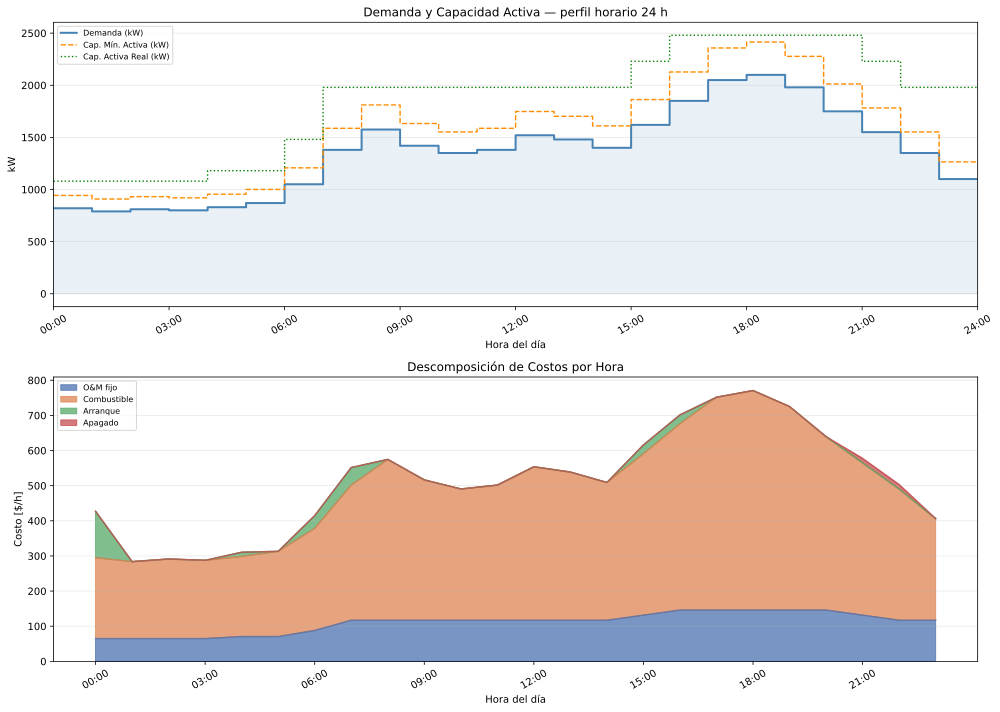

In [129]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']
sns.set_palette(sns.color_palette("deep"))

# Con 24 períodos horarios el "escalón" de cada período dura exactamente 1 hora,
# así que alcanza con usar la hora como coordenada X directamente.
hours       = list(range(24))
demand_vals = list(time_period_data['expected_demand'])
min_cap_vals= list(time_period_data['minimum_active_capacity'])
act_cap_vals= list(results_summary['Cap. Activa Real (kW)'])

# Construir señal de escalones: cada valor se extiende desde h hasta h+1
def make_step(values):
    xs, ys = [], []
    for h, v in enumerate(values):
        xs += [h, h + 1]
        ys += [v, v]
    return xs, ys

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Gráfico 1: Demanda vs capacidad activa ────────────────────────────────────
ax1 = axes[0]
xs_d,  ys_d  = make_step(demand_vals)
xs_mc, ys_mc = make_step(min_cap_vals)
xs_ac, ys_ac = make_step(act_cap_vals)

ax1.fill_between(xs_d, ys_d, alpha=0.12, color='steelblue', step=None)
ax1.plot(xs_d,  ys_d,  color='steelblue',  lw=2,         label='Demanda (kW)')
ax1.plot(xs_mc, ys_mc, color='darkorange',  lw=1.4, ls='--', label='Cap. Mín. Activa (kW)')
ax1.plot(xs_ac, ys_ac, color='green',       lw=1.4, ls=':',  label='Cap. Activa Real (kW)')

ax1.set_xlabel("Hora del día")
ax1.set_ylabel("kW")
ax1.set_title("Demanda y Capacidad Activa — perfil horario 24 h")
ax1.set_xlim(0, 24)
ax1.set_xticks(range(0, 25, 3))
ax1.set_xticklabels([f'{h:02d}:00' for h in range(0, 25, 3)], rotation=30)
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(alpha=0.3, axis='y')

# ── Gráfico 2: Descomposición de costos por hora ──────────────────────────────
ax2 = axes[1]
period_costs = pd.DataFrame(index=hours)
for component, label in [
    ('cost_fixed ($)',    'O&M fijo'),
    ('cost_fuel ($)',     'Combustible'),
    ('cost_startup ($)',  'Arranque'),
    ('cost_shutdown ($)', 'Apagado'),
]:
    period_costs[label] = solution.groupby('time_period')[component].sum().values

period_costs.plot.area(ax=ax2, alpha=0.75)
ax2.set_xlabel("Hora del día"); ax2.set_ylabel("Costo [$/h]")
ax2.set_title("Descomposición de Costos por Hora")
ax2.set_xticks(range(0, 24, 3))
ax2.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)], rotation=30)
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [130]:
active_matrix = pd.DataFrame(
    index=GENERATORS,
    columns=[str(t.time()) for t in TIME_PERIODS],
    data=[
        [int(round(pe.value(model.num_active[g, i]))) for i in T]
        for g in GENERATORS
    ]
)

output_matrix = pd.DataFrame(
    index=GENERATORS,
    columns=[str(t.time()) for t in TIME_PERIODS],
    data=[
        [round(pe.value(model.output[g, i]), 1) for i in T]
        for g in GENERATORS
    ]
)

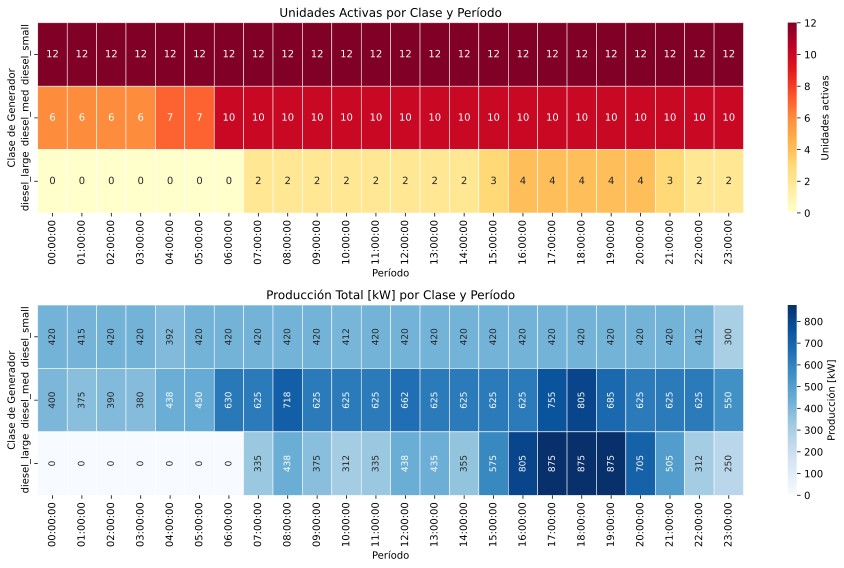

In [131]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

sns.heatmap(active_matrix, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Unidades activas'}, ax=axes[0])
axes[0].set_title("Unidades Activas por Clase y Período")
axes[0].set_xlabel("Período"); axes[0].set_ylabel("Clase de Generador")

sns.heatmap(output_matrix, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Producción [kW]'},
            annot_kws={"size": 9, "rotation": 90},
            ax=axes[1])
axes[1].set_title("Producción Total [kW] por Clase y Período")
axes[1].set_xlabel("Período"); axes[1].set_ylabel("Clase de Generador")

plt.tight_layout()
plt.show()

### Mix de Generación y Curva de Duración de Carga

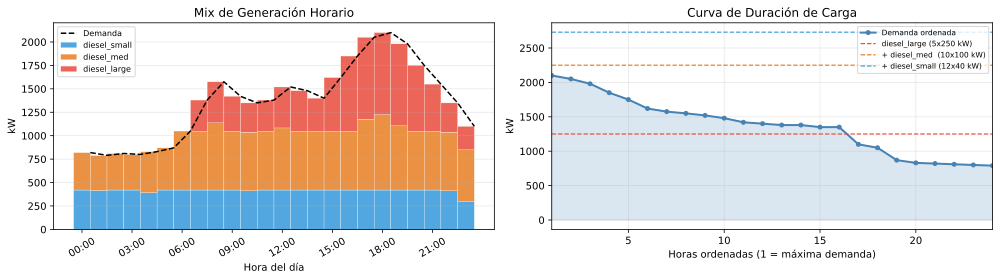

In [132]:
# ── Mix de generación horario (área apilada) ─────────────────────────────────
gen_colors = {'diesel_small': '#3498db', 'diesel_med': '#e67e22', 'diesel_large': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax1 = axes[0]
bottoms = np.zeros(24)
for g in GENERATORS:
    vals = [pe.value(model.output[g, i]) for i in T]
    ax1.bar(hours, vals, bottom=bottoms, color=gen_colors[g],
            alpha=0.85, label=g, width=1.0, edgecolor='white', linewidth=0.3)
    bottoms += np.array(vals)

# Superponer curva de demanda
ax1.plot([h + 0.5 for h in hours], demand_vals, 'k--', lw=1.5, label='Demanda', zorder=5)
ax1.set_xlabel("Hora del día"); ax1.set_ylabel("kW")
ax1.set_title("Mix de Generación Horario")
ax1.set_xticks(range(0, 24, 3)); ax1.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)], rotation=30)
ax1.legend(fontsize=8); ax1.grid(alpha=0.3, axis='y')

# ── Curva de duración de carga (Load Duration Curve) ─────────────────────────
ax2 = axes[1]
sorted_demand = sorted(demand_vals, reverse=True)
ax2.fill_between(range(1, 25), sorted_demand, alpha=0.2, color='steelblue')
ax2.plot(range(1, 25), sorted_demand, 'steelblue', lw=2, marker='o', ms=4, label='Demanda ordenada')

# Líneas de referencia de capacidad instalada por clase
cap_lines = [
    (5 * 250,             'diesel_large (5x250 kW)', '#e74c3c'),
    (5*250 + 10*100,      '+ diesel_med  (10x100 kW)', '#e67e22'),
    (5*250 + 10*100 + 12*40, '+ diesel_small (12x40 kW)', '#3498db'),
]
for cap, lbl, col in cap_lines:
    ax2.axhline(cap, color=col, lw=1.2, ls='--', label=lbl)

ax2.set_xlabel("Horas ordenadas (1 = máxima demanda)"); ax2.set_ylabel("kW")
ax2.set_title("Curva de Duración de Carga")
ax2.set_xlim(1, 24); ax2.legend(fontsize=7.5, loc='upper right'); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

La Curva de Duración de Carga (CDC) es una forma de representar la demanda que no muestra *cuándo* ocurre cada valor, sino *cuántas horas* el sistema necesita abastecer al menos ese nivel de potencia. Se construye tomando las 24 demandas horarias y ordenándolas de mayor a menor:
- Eje X: posición en el ranking (1 = la hora de mayor demanda, 24 = la de menor)
- Eje Y: valor de demanda en kW

Entonces el punto (1, 2100) significa "durante al menos 1 hora al día la demanda es ≥ 2100 kW", y el punto (20, 830) significa "durante al menos 20 horas al día la demanda es ≥ 830 kW". Las líneas de referencia de capacidad te dicen cuánta potencia instalada aportaría cada clase si estuviera toda encendida:
- Roja (1250 kW): solo los 5 `diesel_large`
- Naranja (2250 kW): `diesel_large` + `diesel_med`
- Azul (2730 kW): toda la flota

La interpretación práctica es la siguiente. Mirando dónde la curva de demanda cruza cada línea de referencia podés estimar qué clases de generadores operan como base (siempre encendidos), cuáles cubren carga media y cuáles solo se necesitan en pico:

- Las `diesel_large` solas (1250 kW) no alcanzan nunca → siempre necesitás `diesel_med` también
- La combinación `large` + `med` (2250 kW) cubre la demanda durante la mayoría de las horas, salvo el pico vespertino donde entrás en zona azul y necesitás algunas `diesel_small`

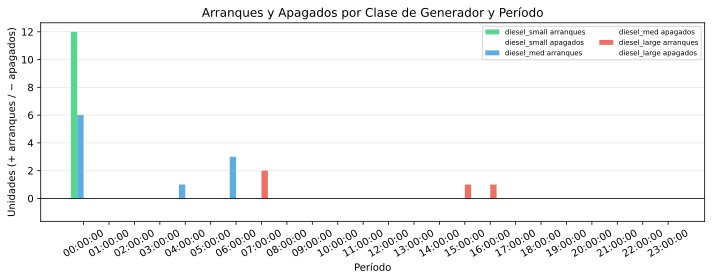

In [133]:
# ── Visualización de arranques y apagados ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
width = 0.25
x = np.arange(len(TIME_PERIODS))
labels = [str(t.time()) for t in TIME_PERIODS]
colors_start = ['#2ecc71', '#3498db', '#e74c3c']
colors_stop  = ['#27ae60', '#2980b9', '#c0392b']

for idx, g in enumerate(GENERATORS):
    starts = [int(round(pe.value(model.num_startup[g, i])))  for i in T]
    stops  = [int(round(pe.value(model.num_shutdown[g, i]))) for i in T]
    offset = (idx - 1) * width
    ax.bar(x + offset - width/2, starts, width, color=colors_start[idx], alpha=0.8, label=f'{g} arranques')
    ax.bar(x + offset - width/2, [-s for s in stops], width, color=colors_stop[idx], alpha=0.4, hatch='//', label=f'{g} apagados')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30)
ax.set_xlabel("Período"); ax.set_ylabel("Unidades (+ arranques / − apagados)")
ax.set_title("Arranques y Apagados por Clase de Generador y Período")
ax.legend(fontsize=7, ncol=2, loc='upper right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Análisis de Rampa: Verificación de Restricciones

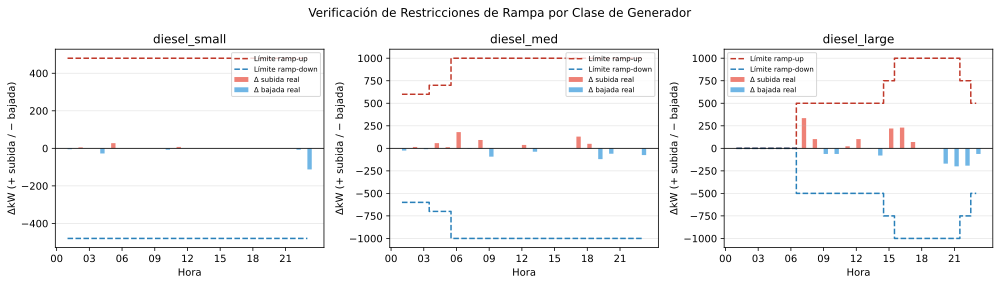


Violaciones de rampa (debe ser 0 en solución óptima):
Clase            Ramp-up activo   Ramp-down activo
--------------------------------------------------
diesel_small                  0                  0
diesel_med                    0                  0
diesel_large                  0                  0


In [134]:
# ── Verificación visual de las restricciones de rampa ────────────────────────
# Para cada clase: Δoutput real vs límite permitido por la rampa

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Verificación de Restricciones de Rampa por Clase de Generador', fontsize=12)

for ax, g in zip(axes, GENERATORS):
    output_vals  = [pe.value(model.output[g, i])    for i in T]
    active_vals  = [int(round(pe.value(model.num_active[g, i])))  for i in T]
    startup_vals = [int(round(pe.value(model.num_startup[g, i]))) for i in T]
    shutdn_vals  = [int(round(pe.value(model.num_shutdown[g, i]))) for i in T]

    delta_up   = []   # incremento real de producción
    delta_down = []   # decremento real de producción
    limit_up   = []   # límite ramp-up permitido
    limit_down = []   # límite ramp-down permitido

    for i in range(1, len(T)):
        diff = output_vals[i] - output_vals[i-1]
        delta_up.append(max(diff, 0))
        delta_down.append(max(-diff, 0))
        limit_up.append(ramp_limit[g] * active_vals[i-1] + max_output[g] * startup_vals[i])
        limit_down.append(ramp_limit[g] * active_vals[i] + max_output[g] * shutdn_vals[i])

    hours_mid = list(range(1, 24))

    ax.bar(hours_mid, delta_up,    color='#e74c3c', alpha=0.7, width=0.4,  label='Δ subida real',    align='edge')
    ax.bar(hours_mid, [-d for d in delta_down], color='#3498db', alpha=0.7, width=0.4, label='Δ bajada real', align='edge')
    ax.step(hours_mid, limit_up,    color='#c0392b', lw=1.5, ls='--', where='mid', label='Límite ramp-up')
    ax.step(hours_mid, [-l for l in limit_down], color='#2980b9', lw=1.5, ls='--', where='mid', label='Límite ramp-down')

    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(g); ax.set_xlabel('Hora'); ax.set_ylabel('ΔkW (+ subida / − bajada)')
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f'{h:02d}' for h in range(0, 24, 3)])
    ax.legend(fontsize=7); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── Tabla resumen: ¿cuántas veces estuvo activa la restricción de rampa? ──────
print('\nViolaciones de rampa (debe ser 0 en solución óptima):')
print(f'{"Clase":<14} {"Ramp-up activo":>16} {"Ramp-down activo":>18}')
print('-' * 50)
for g in GENERATORS:
    output_vals  = [pe.value(model.output[g, i]) for i in T]
    active_vals  = [int(round(pe.value(model.num_active[g, i])))  for i in T]
    startup_vals = [int(round(pe.value(model.num_startup[g, i]))) for i in T]
    shutdn_vals  = [int(round(pe.value(model.num_shutdown[g, i]))) for i in T]
    n_up = n_dn = 0
    for i in range(1, len(T)):
        lim_up = ramp_limit[g]*active_vals[i-1] + max_output[g]*startup_vals[i]
        lim_dn = ramp_limit[g]*active_vals[i]   + max_output[g]*shutdn_vals[i]
        diff = output_vals[i] - output_vals[i-1]
        if diff > lim_up + 1e-4: n_up += 1
        if -diff > lim_dn + 1e-4: n_dn += 1
    print(f'{g:<14} {n_up:>16} {n_dn:>18}')


Se observa que las barras llenas nunca superan las líneas discontinuas, con lo cual se verifica que las soluciones son factibles.

In [135]:
print("\nEstadísticas globales:")
print(f"   Costo total óptimo   : ${costo_total:,.2f}")
print(f"   Clases generadores   : {len(GENERATORS)}")
print(f"   Períodos             : {len(T)}")
print(f"   Total unidades       : {sum(num_available.values())}")
print(f"   Segmentos lin.       : {N_SEG}")

total_starts = sum(int(round(pe.value(model.num_startup[g, i])))  for g in GENERATORS for i in T)
total_stops  = sum(int(round(pe.value(model.num_shutdown[g, i]))) for g in GENERATORS for i in T)
print(f"   Total arranques      : {total_starts}")
print(f"   Total apagados       : {total_stops}")
print(f"   Costo medio por kWh  : ${costo_total / sum(expected_demand.values()):.4f}/kWh")


Estadísticas globales:
   Costo total óptimo   : $12,255.30
   Clases generadores   : 3
   Períodos             : 24
   Total unidades       : 27
   Segmentos lin.       : 3
   Total arranques      : 26
   Total apagados       : 2
   Costo medio por kWh  : $0.3734/kWh


### Análisis Económico: Costos Unitarios y Comparación de Componentes

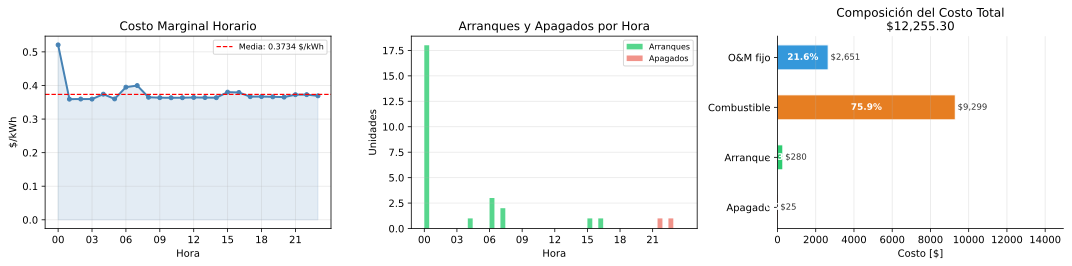


Resumen económico por clase de generador:
Clase           Energía (kWh)  Horas activo  C. Total ($)    $/kWh  Factor uso
----------------------------------------------------------------------------
diesel_small             9912           288       3570.90   0.3602       0.860
diesel_med              14112           218       5280.15   0.3741       0.588
diesel_large             8800            46       3404.22   0.3868       0.293
----------------------------------------------------------------------------
TOTAL                   32825                    12255.30   0.3734


In [136]:
# ── Costo marginal horario ($/kWh) ────────────────────────────────────────────
hourly_cost = period_costs.sum(axis=1).values       # costo total $/h por hora
hourly_cost_per_kwh = hourly_cost / np.array(demand_vals)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

# 1. Costo marginal horario
ax1 = axes[0]
ax1.plot(hours, hourly_cost_per_kwh, 'steelblue', lw=2, marker='o', ms=4)
ax1.fill_between(hours, hourly_cost_per_kwh, alpha=0.15, color='steelblue')
ax1.axhline(costo_total / sum(demand_vals), color='red', lw=1.2, ls='--',
            label=f'Media: {costo_total/sum(demand_vals):.4f} $/kWh')
ax1.set_xlabel("Hora"); ax1.set_ylabel("$/kWh")
ax1.set_title("Costo Marginal Horario")
ax1.set_xticks(range(0, 24, 3)); ax1.set_xticklabels([f'{h:02d}' for h in range(0, 24, 3)])
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# 2. Arranques y apagados acumulados por hora
ax2 = axes[1]
starts_total = [sum(int(round(pe.value(model.num_startup[g, i])))  for g in GENERATORS) for i in T]
stops_total  = [sum(int(round(pe.value(model.num_shutdown[g, i]))) for g in GENERATORS) for i in T]

ax2.bar(hours, starts_total,               color='#2ecc71', alpha=0.8, label='Arranques',  width=0.45, align='edge')
ax2.bar([h + 0.45 for h in hours], stops_total, color='#e74c3c', alpha=0.6, label='Apagados', width=0.45, align='edge')
ax2.set_xlabel("Hora"); ax2.set_ylabel("Unidades")
ax2.set_title("Arranques y Apagados por Hora")
ax2.set_xticks(range(0, 24, 3)); ax2.set_xticklabels([f'{h:02d}' for h in range(0, 24, 3)])
ax2.legend(fontsize=8); ax2.grid(alpha=0.3, axis='y')

# 3. Comparación de componentes de costo (barras apiladas)
ax3 = axes[2]

cost_components = {
    'O&M fijo':    period_costs['O&M fijo'].sum(),
    'Combustible': period_costs['Combustible'].sum(),
    'Arranque':    period_costs['Arranque'].sum(),
    'Apagado':     period_costs['Apagado'].sum(),
}
wedge_colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']

labels  = list(cost_components.keys())
values  = list(cost_components.values())
total   = sum(values)
pcts    = [v / total * 100 for v in values]

bars = ax3.barh(labels, values, color=wedge_colors, edgecolor='white', height=0.5)

# Etiqueta dentro de la barra: porcentaje
for bar, pct, val in zip(bars, pcts, values):
    x_center = bar.get_width() / 2
    ax3.text(x_center, bar.get_y() + bar.get_height() / 2,
             f'{pct:.1f}%', ha='center', va='center',
             fontsize=9, fontweight='bold', color='white')
    # Etiqueta fuera de la barra: valor en $
    ax3.text(bar.get_width() + total * 0.01, bar.get_y() + bar.get_height() / 2,
             f'${val:,.0f}', ha='left', va='center', fontsize=8.5, color='#333333')

ax3.set_xlabel("Costo [$]")
ax3.set_title(f"Composición del Costo Total\n${costo_total:,.2f}")
ax3.set_xlim(0, total * 1.22)   # margen derecho para las etiquetas $
ax3.invert_yaxis()               # mayor arriba
ax3.grid(alpha=0.3, axis='x')
ax3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# ── Tabla resumen por clase de generador ─────────────────────────────────────
print("\nResumen económico por clase de generador:")
print(f"{'Clase':<14} {'Energía (kWh)':>14} {'Horas activo':>13} {'C. Total ($)':>13} {'$/kWh':>8} {'Factor uso':>11}")
print("-" * 76)
for g in GENERATORS:
    energia  = sum(pe.value(model.output[g, i]) for i in T)           # kWh (1 h/período)
    h_activo = sum(int(round(pe.value(model.num_active[g, i]))) for i in T)  # unit·h
    c_tot    = solution.loc[g, 'cost_total ($)'].sum()
    max_cap  = generator_data.loc[g, 'max_output'] * generator_data.loc[g, 'num_available']
    f_uso    = energia / (max_cap * 24)
    print(f"{g:<14} {energia:>14.0f} {h_activo:>13d} {c_tot:>13.2f} {c_tot/energia if energia>0 else 0:>8.4f} {f_uso:>11.3f}")
print("-" * 76)
print(f"{'TOTAL':<14} {sum(demand_vals):>14.0f} {'':>13} {costo_total:>13.2f} {costo_total/sum(demand_vals):>8.4f}")

## Conclusiones

Este modelo implementa un **Unit Commitment + Despacho Económico** para una microrred diesel con las siguientes extensiones sobre el ejemplo original de Williams:

1. **Redimensionamiento a escala de microrred:** la demanda fue escalada de ~45 GW (problema nacional) a ~2,1 MW (pico de microrred), con tres clases de generadores diesel de 40, 100 y 250 kW.

2. **Costos de apagado:** la variable `num_shutdown` y el parámetro `shutdown_cost` capturan los costos de detención de los grupos diesel (fijados en el 50% del costo de arranque, según Nemati et al.).

3. **Tiempos mínimos de encendido/apagado:** las restricciones MUT y MDT obligan a las unidades a permanecer en su estado actual por al menos el tiempo indicado tras un cambio, evitando el ciclado excesivo y respetando las recomendaciones de Parisio (2014).

4. **Linealización Parisio de la curva de combustible:** la variable auxiliar $\sigma_{g,t}$ y las restricciones de segmentos tangentes reemplazan el término cuadrático de consumo de combustible por una aproximación lineal convexa por partes, manteniendo la naturaleza MILP del problema (más eficiente que MIQP).

5. **Restricciones de rampa (V4):** las restricciones ramp-up y ramp-down limitan el cambio de producción entre períodos consecutivos al 50% de $P^{\max}_g$ por hora. La formulación empleada descuenta correctamente el efecto de arranques y apagados:
   - $x_{g,t} - x_{g,t-1} \leq R_g \cdot n_{g,t-1} + P^{\max}_g \cdot u_{g,t}$ (rampa subida)
   - $x_{g,t-1} - x_{g,t} \leq R_g \cdot n_{g,t} + P^{\max}_g \cdot v_{g,t}$ (rampa bajada)
   Esto obliga al sistema a anticipar rampas de demanda encendiendo unidades con anticipación, protege mecánicamente los motores y refleja la operación real de microrredes aisladas.

6. **Descomposición de costos:** el modelo desglosa el costo total en cuatro componentes (O&M, combustible, arranque, apagado), facilitando el análisis económico de la operación de la microrred.
